## Imports and output directory


In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path("output") / "Arg_pathway_sim"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figure output directory: {OUTPUT_DIR.resolve()}")

"""
2D parameter sweep over the ArgO exporter kinetics (Vmax_export, Km_export_Arg).

For each combination on a log-spaced grid, runs the unclamped batch model for 60 h
(cofactors deplete, no regeneration, biomass fixed at X0 = 0.1 g/L) and records
the final extracellular arginine concentration.

Outputs:
  argO_sweep_results.csv  — long format (Vmax, Km, Arg_e) per row
  argO_sweep_pivot.csv    — wide format (rows = Vmax, cols = Km)
  argO_sweep_heatmap.png  — heatmap + contour visualisation
  printed summary with corner/centre values, max/min, and nominal
"""

# =============================================================================
# PARAMETERS


Figure output directory: C:\Users\bcsma\OneDrive - Imperial College London\Documents\Ben\Post-doc\SimCells-for-Cultured-Meat\output\Arg_pathway_sim


'\n2D parameter sweep over the ArgO exporter kinetics (Vmax_export, Km_export_Arg).\n\nFor each combination on a log-spaced grid, runs the unclamped batch model for 60 h\n(cofactors deplete, no regeneration, biomass fixed at X0 = 0.1 g/L) and records\nthe final extracellular arginine concentration.\n\nOutputs:\n  argO_sweep_results.csv  — long format (Vmax, Km, Arg_e) per row\n  argO_sweep_pivot.csv    — wide format (rows = Vmax, cols = Km)\n  argO_sweep_heatmap.png  — heatmap + contour visualisation\n  printed summary with corner/centre values, max/min, and nominal\n'

## Nominal kinetic parameters (Vmax, Km), biomass and batch setup


In [2]:
# =============================================================================
np.random.seed(42)

Vmax_nominal = {
    'ghdA':      1.5,        # GDH
    'argJ_init': 0.0,        # ACGS initiation
    'argB':      0.0589,     # NAGK
    'argC':      0.193,      # NAGSD
    'argD':      0.0064,     # ACOAT
    'argJ_cyc':  1.14,       # OAT recycling
    'argF':      1.06,       # OTC
    'argG':      1.94,       # AS
    'argH':      0.01971,    # AL
}

# Km values (mM)
Km_nominal = {
    'ghdA_aKG':     3.25,
    'ghdA_NH4':     36.0,
    'ghdA_NADPH':   0.083,
    'argB_AcGlu':   3.42,
    'argC_AcG5P':   0.6,
    'argD_AcG5SA':  0.48,
    'argJ_AcOrn':   2.7,
    'argJ_Glu':     19.2,
    'Ki_Orn':       2.3,
    'argF_Orn':     2.4,
    'argF_CbmP':    0.27,
    'argG_Citr':    0.044,
    'argG_Asp':     0.18,
    'argG_ATP':     0.11,
    'argH_ArgSuc':  0.144,
}

# Biomass / scaling
f_protein = 0.55     # protein fraction of DCW
X0 = 0.1             # g/L

# Initial cofactor concentrations (deplete during the run)
batch_init = {
    'aKG':      0.44,
    'NH4':      10.0,    # from medium
    'NADPH':    0.12,
    'ATP':      9.6,
    'AcCoA':    0.61,
    'CbmP':     0.3,
    'Asp':      4.2,
}

# Nominal ArgO reference values
Vmax_export_nominal = 0.012   # µmol/min/mg DCW
Km_export_nominal   = 20.0    # mM

# =============================================================================
# MODEL FUNCTION


## `run_model_argO` — batch pathway with ArgO export


In [3]:
# =============================================================================
def run_model_argO(Vmax_export, Km_export_Arg):
    """
    Unclamped batch run with specified ArgO export kinetics. All other
    parameters at nominal. Returns final Arg_e in g/L (NaN on solver failure).
    """
    def odes(t, y):
        vals = [max(v, 0) for v in y]
        Glu, AcGlu, AcG5P, AcG5SA, AcOrn, Orn, Citr, ArgSuc, Arg_i, Arg_e, \
            aKG, NH4, NADPH, ATP, CbmP, Asp = vals

        scale = X0 * f_protein
        scale_exp = X0

        # ghdA: αKG + NH4 + NADPH → Glu
        r_ghdA = Vmax_nominal['ghdA'] \
            * (aKG / (Km_nominal['ghdA_aKG'] + aKG)) \
            * (NH4 / (Km_nominal['ghdA_NH4'] + NH4)) \
            * (NADPH / (Km_nominal['ghdA_NADPH'] + NADPH))

        # argB: AcGlu + ATP → AcG5P
        r_argB = Vmax_nominal['argB'] * AcGlu / (Km_nominal['argB_AcGlu'] + AcGlu) \
                 * ATP / (Km_nominal['argG_ATP'] + ATP)

        # argC: AcG5P + NADPH → AcG5SA
        r_argC = Vmax_nominal['argC'] * AcG5P / (Km_nominal['argC_AcG5P'] + AcG5P) \
                 * NADPH / (Km_nominal['ghdA_NADPH'] + NADPH)

        # argD: AcG5SA → AcOrn
        r_argD = Vmax_nominal['argD'] * AcG5SA / (Km_nominal['argD_AcG5SA'] + AcG5SA)

        # argJ recycling (ping-pong bi-bi with Orn product inhibition)
        denom_J = AcOrn * Glu \
                  + Km_nominal['argJ_Glu'] * AcOrn * (1 + Orn / Km_nominal['Ki_Orn']) \
                  + Km_nominal['argJ_AcOrn'] * Glu
        r_argJ = Vmax_nominal['argJ_cyc'] * AcOrn * Glu / denom_J if denom_J > 0 else 0

        # argF: Orn + CbmP → Citr (ordered bi-bi)
        denom_F = Orn * CbmP \
                  + Km_nominal['argF_Orn'] * CbmP \
                  + Km_nominal['argF_CbmP'] * Orn \
                  + Km_nominal['argF_Orn'] * Km_nominal['argF_CbmP']
        r_argF = Vmax_nominal['argF'] * Orn * CbmP / denom_F if denom_F > 0 else 0

        # argG: Citr + Asp + ATP → ArgSuc
        denom_G = Citr * Asp \
                  + Km_nominal['argG_Citr'] * Asp \
                  + Km_nominal['argG_Asp'] * Citr \
                  + Km_nominal['argG_Citr'] * Km_nominal['argG_Asp']
        r_argG = Vmax_nominal['argG'] * Citr * Asp / denom_G \
                 * ATP / (Km_nominal['argG_ATP'] + ATP) if denom_G > 0 else 0

        # argH: ArgSuc → Arg
        r_argH = Vmax_nominal['argH'] * ArgSuc / (Km_nominal['argH_ArgSuc'] + ArgSuc)

        # ArgO export
        r_export = Vmax_export * Arg_i / (Km_export_Arg + Arg_i)

        # Pathway ODEs
        dGlu     = scale * (r_ghdA - r_argJ)
        dAcGlu   = scale * (r_argJ - r_argB)
        dAcG5P   = scale * (r_argB - r_argC)
        dAcG5SA  = scale * (r_argC - r_argD)
        dAcOrn   = scale * (r_argD - r_argJ)
        dOrn     = scale * (r_argJ - r_argF)
        dCitr    = scale * (r_argF - r_argG)
        dArgSuc  = scale * (r_argG - r_argH)
        dArg_i   = scale * r_argH - scale_exp * r_export
        dArg_e   = scale_exp * r_export

        # Cofactor depletion (no regeneration in batch)
        daKG   = -scale * r_ghdA
        dNH4   = -scale * r_ghdA
        dNADPH = -scale * (r_ghdA + r_argC)
        dATP   = -scale * (r_argB + r_argG)
        dCbmP  = -scale * r_argF
        dAsp   = -scale * r_argG

        return [dGlu, dAcGlu, dAcG5P, dAcG5SA, dAcOrn, dOrn, dCitr, dArgSuc, dArg_i, dArg_e,
                daKG, dNH4, dNADPH, dATP, dCbmP, dAsp]

    y0 = [
        100.0, 0.1, 0.01, 0.01, 0.01, 0.1, 0.01, 0.01, 0.5, 0.0,
        batch_init['aKG'], batch_init['NH4'], batch_init['NADPH'],
        batch_init['ATP'], batch_init['CbmP'], batch_init['Asp'],
    ]

    sol = solve_ivp(odes, (0, 3600), y0, method='LSODA',
                    rtol=1e-8, atol=1e-10, max_step=1.0, t_eval=[3600])

    if sol.success:
        return sol.y[9, -1] * 174.2 / 1000   # Arg_e in g/L (M_arg = 174.2 g/mol)
    return np.nan

# =============================================================================
# 2D SWEEP CONFIGURATION


## 2D sweep grid (`Km`, `Vmax_export`) configuration


In [4]:
# =============================================================================
N_grid = 20
Km_low,   Km_high   = 5.0,   50.0     # mM
Vmax_low, Vmax_high = 0.001, 0.1      # µmol/min/mg DCW

Km_grid   = np.logspace(np.log10(Km_low),   np.log10(Km_high),   N_grid)
Vmax_grid = np.logspace(np.log10(Vmax_low), np.log10(Vmax_high), N_grid)

print(f"2D ArgO sweep: {N_grid} × {N_grid} = {N_grid**2} runs")
print(f"  Vmax_export: [{Vmax_low}, {Vmax_high}] µmol/min/mg DCW (log-spaced)")
print(f"  Km_export:   [{Km_low}, {Km_high}] mM (log-spaced)")
print(f"  All other parameters at nominal; 60 h batch with depleting cofactors\n")

# =============================================================================
# RUN SWEEP


2D ArgO sweep: 20 × 20 = 400 runs
  Vmax_export: [0.001, 0.1] µmol/min/mg DCW (log-spaced)
  Km_export:   [5.0, 50.0] mM (log-spaced)
  All other parameters at nominal; 60 h batch with depleting cofactors



## Execute parameter sweep (`results` grid)


In [5]:
# =============================================================================
# results[i, j] = Arg_e for Vmax_grid[i], Km_grid[j]
results = np.zeros((N_grid, N_grid))
n_done = 0
n_total = N_grid * N_grid

for i, Vmax in enumerate(Vmax_grid):
    for j, Km in enumerate(Km_grid):
        results[i, j] = run_model_argO(Vmax, Km)
        n_done += 1
        if n_done % 50 == 0:
            print(f"  {n_done}/{n_total} runs complete...")

# Nominal reference
nominal_arg = run_model_argO(Vmax_export_nominal, Km_export_nominal)

n_ok = np.sum(~np.isnan(results))
print(f"\nSuccessful runs: {n_ok}/{n_total}")
print(f"Arg_e range across grid: [{np.nanmin(results):.4f}, {np.nanmax(results):.4f}] g/L")
print(f"Nominal Arg_e (Vmax={Vmax_export_nominal}, Km={Km_export_nominal}): "
      f"{nominal_arg:.4f} g/L\n")

# =============================================================================
# SAVE RESULTS TABLES


  50/400 runs complete...
  100/400 runs complete...
  150/400 runs complete...
  200/400 runs complete...
  250/400 runs complete...
  300/400 runs complete...
  350/400 runs complete...
  400/400 runs complete...

Successful runs: 400/400
Arg_e range across grid: [0.0008, 0.1128] g/L
Nominal Arg_e (Vmax=0.012, Km=20.0): 0.0209 g/L



## Build sweep tables and save CSVs


In [6]:
# =============================================================================
# Long format: one row per (Vmax, Km, Arg_e)
rows = []
for i, Vmax in enumerate(Vmax_grid):
    for j, Km in enumerate(Km_grid):
        rows.append({
            'Vmax_export_umol_min_mg': Vmax,
            'Km_export_Arg_mM':        Km,
            'Arg_e_gL':                results[i, j],
        })
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / 'argO_sweep_results.csv', index=False)
print("Long-format results saved to argO_sweep_results.csv")

# Wide format: rows = Vmax, columns = Km, values = Arg_e
pivot = df.pivot(index='Vmax_export_umol_min_mg',
                 columns='Km_export_Arg_mM',
                 values='Arg_e_gL')
pivot.to_csv(OUTPUT_DIR / 'argO_sweep_pivot.csv')
print("Wide-format pivot saved to argO_sweep_pivot.csv\n")

# =============================================================================
# PRINT SUMMARY TABLE


Long-format results saved to argO_sweep_results.csv
Wide-format pivot saved to argO_sweep_pivot.csv



## Sweep summary (printed corner / extrema / nominal)


In [7]:
# =============================================================================
print("=" * 82)
print("ARGO SWEEP SUMMARY — final extracellular arginine (g/L)")
print("=" * 82)

# Corner / centre table
mid = N_grid // 2
print(f"\n{'':30}{'Km low':>14}{'Km mid':>14}{'Km high':>14}")
print(f"{'':30}{f'({Km_grid[0]:.2f} mM)':>14}{f'({Km_grid[mid]:.2f} mM)':>14}{f'({Km_grid[-1]:.2f} mM)':>14}")
print("-" * 82)
for label, i in [('Vmax low ', 0), ('Vmax mid ', mid), ('Vmax high', N_grid - 1)]:
    print(f"  {label} ({Vmax_grid[i]:.4f} µmol/min/mg)  "
          f"{results[i, 0]:>12.4f}  {results[i, mid]:>12.4f}  {results[i, -1]:>12.4f}")

# Extrema
i_max, j_max = np.unravel_index(np.nanargmax(results), results.shape)
i_min, j_min = np.unravel_index(np.nanargmin(results), results.shape)
print(f"\nMax Arg_e: {results[i_max, j_max]:.4f} g/L  "
      f"at Vmax = {Vmax_grid[i_max]:.4f}, Km = {Km_grid[j_max]:.2f} mM")
print(f"Min Arg_e: {results[i_min, j_min]:.4f} g/L  "
      f"at Vmax = {Vmax_grid[i_min]:.4f}, Km = {Km_grid[j_min]:.2f} mM")
print(f"Nominal:   {nominal_arg:.4f} g/L  "
      f"at Vmax = {Vmax_export_nominal}, Km = {Km_export_nominal} mM")
print("=" * 82)

# =============================================================================

# PLOTTING — HEATMAP + CONTOUR


ARGO SWEEP SUMMARY — final extracellular arginine (g/L)

                                      Km low        Km mid       Km high
                                   (5.00 mM)    (16.80 mM)    (50.00 mM)
----------------------------------------------------------------------------------
  Vmax low  (0.0010 µmol/min/mg)        0.0069        0.0023        0.0008
  Vmax mid  (0.0113 µmol/min/mg)        0.0583        0.0230        0.0085
  Vmax high (0.1000 µmol/min/mg)        0.1128        0.0983        0.0566

Max Arg_e: 0.1128 g/L  at Vmax = 0.1000, Km = 5.00 mM
Min Arg_e: 0.0008 g/L  at Vmax = 0.0010, Km = 50.00 mM
Nominal:   0.0209 g/L  at Vmax = 0.012, Km = 20.0 mM


## Heatmap and contour plots


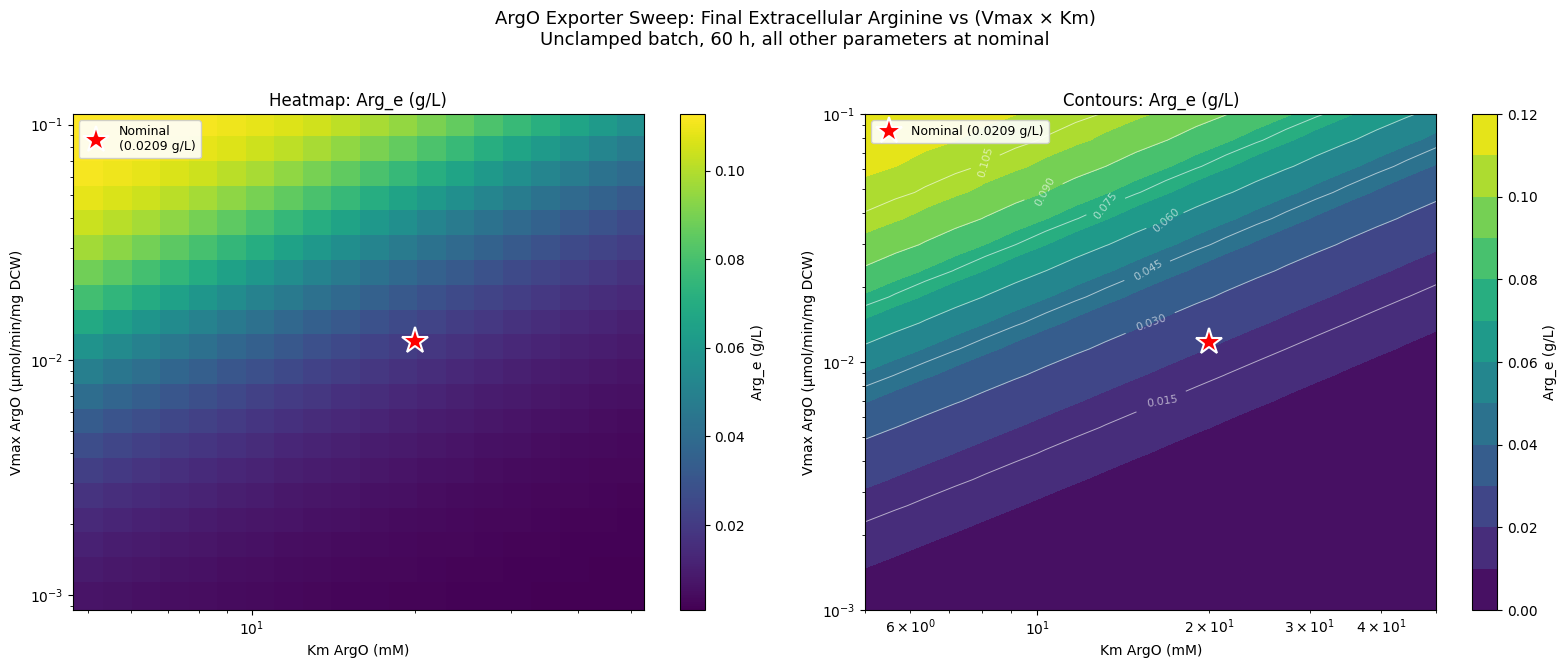

In [8]:
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle('ArgO Exporter Sweep: Final Extracellular Arginine vs (Vmax × Km)\n'
             'Unclamped batch, 60 h, all other parameters at nominal',
             fontsize=13, y=1.02)

KmM, VmaxM = np.meshgrid(Km_grid, Vmax_grid)

# Panel 1: filled heatmap
ax = axes[0]
pcm = ax.pcolormesh(KmM, VmaxM, results, shading='auto', cmap='viridis')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Km ArgO (mM)')
ax.set_ylabel('Vmax ArgO (µmol/min/mg DCW)')
ax.set_title('Heatmap: Arg_e (g/L)')
plt.colorbar(pcm, ax=ax, label='Arg_e (g/L)')
ax.plot(Km_export_nominal, Vmax_export_nominal,
        marker='*', markersize=20,
        markerfacecolor='red', markeredgecolor='white', markeredgewidth=1.5,
        linestyle='none',
        label=f'Nominal\n({nominal_arg:.4f} g/L)')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

# Panel 2: contour overlay
ax = axes[1]
cs_filled = ax.contourf(KmM, VmaxM, results, levels=12, cmap='viridis')
cs_lines = ax.contour(KmM, VmaxM, results, levels=8,
                      colors='white', linewidths=0.7, alpha=0.6)
ax.clabel(cs_lines, inline=True, fontsize=8, fmt='%.3f')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Km ArgO (mM)')
ax.set_ylabel('Vmax ArgO (µmol/min/mg DCW)')
ax.set_title('Contours: Arg_e (g/L)')
plt.colorbar(cs_filled, ax=ax, label='Arg_e (g/L)')
ax.plot(Km_export_nominal, Vmax_export_nominal,
        marker='*', markersize=20,
        markerfacecolor='red', markeredgecolor='white', markeredgewidth=1.5,
        linestyle='none',
        label=f'Nominal ({nominal_arg:.4f} g/L)')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'argO_sweep_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================

# FOLD-CHANGE ANALYSES (OAT + 2D matrix)


## Fold-change analyses (OAT and matrix)



FOLD-CHANGE ANALYSES
Fold values: [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2, 3, 4, 5]
Applied to nominal Vmax = 0.012 µmol/min/mg and Km = 20.0 mM

OAT fold-change table saved to argO_OAT_fold_change.csv

  parameter          fold         value  unit            Arg_e (g/L)
  ------------------------------------------------------------------
  Vmax_export        0.10       0.00120  umol/min/mg          0.0023
  Vmax_export        0.25       0.00300  umol/min/mg          0.0056
  Vmax_export        0.50       0.00600  umol/min/mg          0.0110
  Vmax_export        0.75       0.00900  umol/min/mg          0.0161
  Vmax_export        1.00       0.01200  umol/min/mg          0.0209
  Vmax_export        1.50       0.01800  umol/min/mg          0.0299
  Vmax_export        2.00       0.02400  umol/min/mg          0.0380
  Vmax_export        3.00       0.03600  umol/min/mg          0.0520
  Vmax_export        4.00       0.04800  umol/min/mg          0.0634
  Vmax_export        5.00       0.06000  u

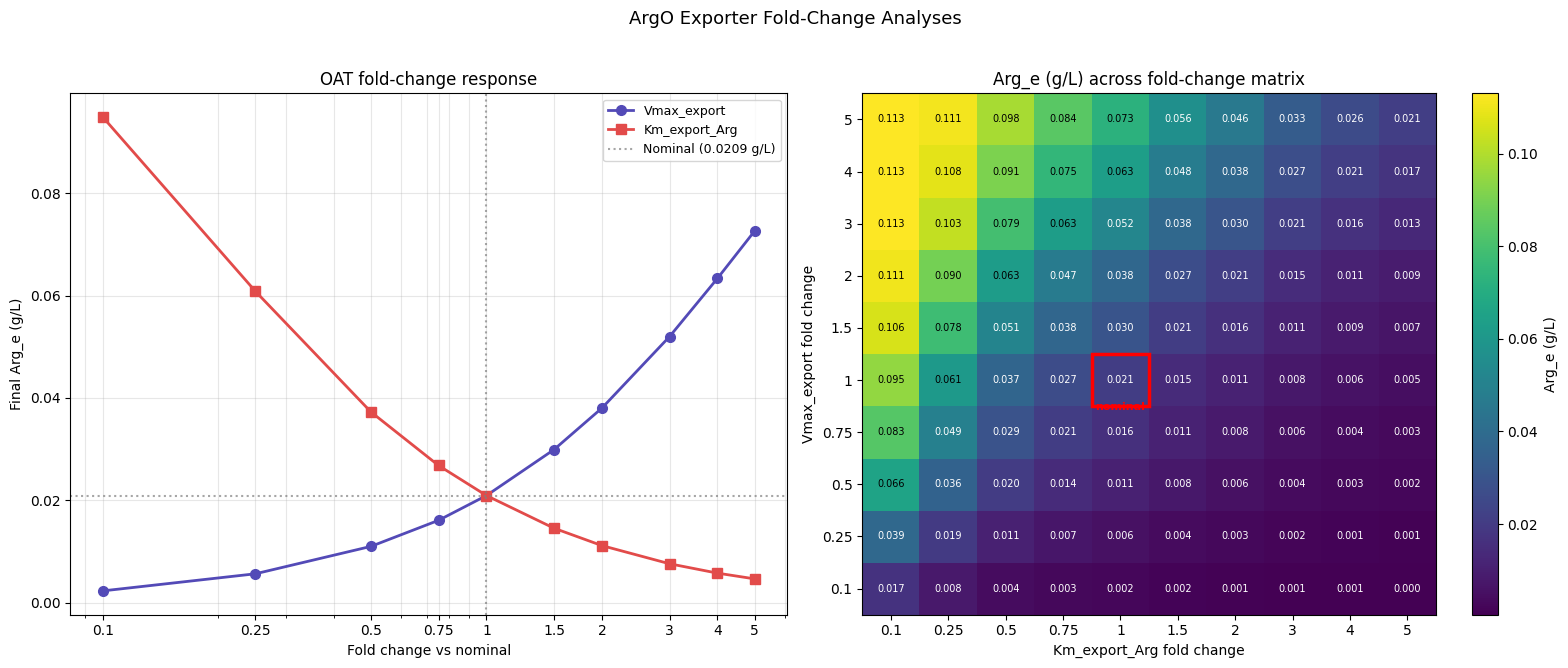

In [9]:
# =============================================================================
# Discrete fold changes; OAT (one at a time) and 2D matrix (all combos).
fold_changes = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2, 3, 4, 5]

print("\n" + "=" * 82)
print("FOLD-CHANGE ANALYSES")
print(f"Fold values: {fold_changes}")
print(f"Applied to nominal Vmax = {Vmax_export_nominal} \u00b5mol/min/mg "
      f"and Km = {Km_export_nominal} mM")
print("=" * 82)

# -----------------------------------------------------------------------------
# OAT fold change
# -----------------------------------------------------------------------------
oat_rows = []

for f in fold_changes:                           # Vmax sweep, Km at nominal
    Vmax_val = Vmax_export_nominal * f
    arg_e = run_model_argO(Vmax_val, Km_export_nominal)
    oat_rows.append({
        'parameter':   'Vmax_export',
        'fold_change': f,
        'value':       Vmax_val,
        'unit':        'umol/min/mg',
        'Arg_e_gL':    arg_e,
    })

for f in fold_changes:                           # Km sweep, Vmax at nominal
    Km_val = Km_export_nominal * f
    arg_e = run_model_argO(Vmax_export_nominal, Km_val)
    oat_rows.append({
        'parameter':   'Km_export_Arg',
        'fold_change': f,
        'value':       Km_val,
        'unit':        'mM',
        'Arg_e_gL':    arg_e,
    })

oat_df = pd.DataFrame(oat_rows)
oat_df.to_csv(OUTPUT_DIR / 'argO_OAT_fold_change.csv', index=False)
print("\nOAT fold-change table saved to argO_OAT_fold_change.csv\n")

# Console-friendly table
print(f"  {'parameter':<16}{'fold':>7}{'value':>14}  {'unit':<14}{'Arg_e (g/L)':>13}")
print("  " + "-" * 66)
for r in oat_rows:
    print(f"  {r['parameter']:<16}{r['fold_change']:>7.2f}{r['value']:>14.5f}  "
          f"{r['unit']:<14}{r['Arg_e_gL']:>13.4f}")

# -----------------------------------------------------------------------------
# 2D fold-change matrix
# -----------------------------------------------------------------------------
nf = len(fold_changes)
matrix = np.zeros((nf, nf))                      # rows = Vmax fold, cols = Km fold
matrix_rows = []

print(f"\nRunning 2D fold-change matrix ({nf}\u00d7{nf} = {nf*nf} runs)...")
for i, fv in enumerate(fold_changes):
    for j, fk in enumerate(fold_changes):
        Vmax_val = Vmax_export_nominal * fv
        Km_val   = Km_export_nominal * fk
        arg_e = run_model_argO(Vmax_val, Km_val)
        matrix[i, j] = arg_e
        matrix_rows.append({
            'Vmax_fold':              fv,
            'Km_fold':                fk,
            'Vmax_value_umol_min_mg': Vmax_val,
            'Km_value_mM':            Km_val,
            'Arg_e_gL':               arg_e,
        })

matrix_long = pd.DataFrame(matrix_rows)
matrix_long.to_csv(OUTPUT_DIR / 'argO_matrix_fold_change.csv', index=False)
matrix_wide = matrix_long.pivot(index='Vmax_fold', columns='Km_fold', values='Arg_e_gL')
matrix_wide.to_csv(OUTPUT_DIR / 'argO_matrix_fold_change_pivot.csv')

print(f"\n2D fold-change matrix saved to:")
print(f"  argO_matrix_fold_change.csv         (long format, {nf*nf} rows)")
print(f"  argO_matrix_fold_change_pivot.csv   (wide format, {nf}\u00d7{nf})")

# Console-friendly wide table
print(f"\n  Arg_e (g/L) \u2014 rows = Vmax fold, cols = Km fold")
header = "    Vmax\\Km  " + "".join(f"{f:>9.2f}" for f in fold_changes)
print(header)
print("  " + "-" * (len(header) - 2))
for i, fv in enumerate(fold_changes):
    print(f"  {fv:>9.2f}  " + "".join(f"{matrix[i, j]:>9.4f}" for j in range(nf)))

# -----------------------------------------------------------------------------
# Plotting: OAT line plot + 2D fold-change heatmap
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle('ArgO Exporter Fold-Change Analyses', fontsize=13, y=1.02)

# Panel 1: OAT line plot
ax = axes[0]
oat_vmax = oat_df[oat_df['parameter'] == 'Vmax_export']
oat_km   = oat_df[oat_df['parameter'] == 'Km_export_Arg']
ax.plot(oat_vmax['fold_change'], oat_vmax['Arg_e_gL'],
        marker='o', linewidth=2, markersize=7, label='Vmax_export', color='#534AB7')
ax.plot(oat_km['fold_change'], oat_km['Arg_e_gL'],
        marker='s', linewidth=2, markersize=7, label='Km_export_Arg', color='#E24B4A')
ax.axvline(1.0, color='gray', linestyle=':', alpha=0.7)
ax.axhline(nominal_arg, color='gray', linestyle=':', alpha=0.7,
           label=f'Nominal ({nominal_arg:.4f} g/L)')
ax.set_xscale('log')
ax.set_xlabel('Fold change vs nominal')
ax.set_ylabel('Final Arg_e (g/L)')
ax.set_title('OAT fold-change response')
ax.set_xticks(fold_changes)
ax.set_xticklabels([f'{f:g}' for f in fold_changes])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

# Panel 2: 2D fold-change matrix heatmap (annotated)
ax = axes[1]
im = ax.imshow(matrix, cmap='viridis', aspect='auto', origin='lower')
ax.set_xticks(range(nf))
ax.set_yticks(range(nf))
ax.set_xticklabels([f'{f:g}' for f in fold_changes])
ax.set_yticklabels([f'{f:g}' for f in fold_changes])
ax.set_xlabel('Km_export_Arg fold change')
ax.set_ylabel('Vmax_export fold change')
ax.set_title('Arg_e (g/L) across fold-change matrix')

# Annotate each cell with its value
m_min, m_max = matrix.min(), matrix.max()
for i in range(nf):
    for j in range(nf):
        norm_val = (matrix[i, j] - m_min) / (m_max - m_min + 1e-12)
        text_color = 'white' if norm_val < 0.5 else 'black'
        ax.text(j, i, f'{matrix[i, j]:.3f}', ha='center', va='center',
                color=text_color, fontsize=7)

plt.colorbar(im, ax=ax, label='Arg_e (g/L)')

# Outline the nominal cell (fold = 1.0, 1.0)
if 1.0 in fold_changes:
    k = fold_changes.index(1.0)
    ax.add_patch(plt.Rectangle((k - 0.5, k - 0.5), 1, 1,
                               fill=False, edgecolor='red', linewidth=2.5))
    ax.text(k, k - 0.42, 'nominal', ha='center', va='top',
            color='red', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'argO_fold_change_plots.png', dpi=150, bbox_inches='tight')
plt.show()
